# Project

## Introduction to the Project
The S&P 500 (Standard & Poor's 500) is a stock market index that tracks the performance of 500 of the largest publicly traded companies in the United States. It is widely regarded as one of the best representations of the U.S. stock market and economy. Over the long term, the S&P 500 has shown consistent growth, making it a key focus for long-term investors. However, it can also experience significant volatility in the short term.

In this project, we will make our first attempt to build a momentum-based strategy to trade the S&P 500 index. At the end of the project, you will have built a program that you can later expand and customise to suit your needs. We will use the python packages numpy, scipy and sqlite3, among others, in this project.

Tips: Review the code snippets that we went through during the course. Reorganize them and you are half-way done! Try experimenting with different configurations of the confidence interval, the lookback window and the forecast horizon. Be brave and experiment with different ways of deciding the position size. You may be surprised by your talent!

Re-organize your code from the exercises into a Python program that 
1. read prices from a database
2. calibrate a GBM model on each day when new prices are received.
3. forecast the price in e.g. 10 days and
   1. calculate the confidence interval of the forecast
   2. calculate the expected shortfall from the price forecast
4. code your trading signals using the price forecast and the expected shortfall.
5. store your postions into the *positions* table after each trade.
6. produce a 1-year backtest record from 2020-06-01 to 2021-05-31.

**Hint**

1. Collect all the code related to the GBM model into a class

In [1]:
import csv
import sqlite3
from contextlib import closing
from datetime import datetime

import numpy as np
from scipy.stats import norm

conn = sqlite3.connect("SP500.db")
cs = conn.cursor()


In [2]:
class GBM:
    def __init__(self, seed=42):
        """Create an uncalibrated model with a reproducible random generator."""

        # Annualized drift and volatility.
        self.mu = np.nan
        self.sigma = np.nan

        # The default seed makes simulations and bootstrap samples repeatable.
        self.rng = np.random.default_rng(seed)
        
    def simulate(self, N, K, Dt, S0):
        """
        Simulate K price paths, each containing N time steps after S0.
        """

        # Matrix of (N+1) rows by K columns 
        # Representing K trajectories of N+1. values with the first beign S0
        traj = np.full((N+1, K), np.nan)
        # TODO: Your code goes here
        # First element of all the trajectories is S0
        traj[0,:] =S0

        # Draw independent standard-normal values for each trajectory and each step.
        standard_normal_values= self.rng.normal(size = (N,K))
        # Compute the log-returns 
        # Under GBM, each log return consists of:
        # 1. a deterministic drift component
        # 2. a random volatility component
        log_returns = (
            (self.mu-self.sigma**2/2) *Dt
            + self.sigma *np.sqrt(Dt) * standard_normal_values 
        )

        # Compute the returns from the starting price S0 
        # Accumulate the log returns through time.
        # Exponentiate them to obtain the expected prices
        traj[1:,:] = S0 * np.exp(np.cumsum(log_returns, axis = 0))

        return traj

    def calibrate(self, trajectory, Dt):
        """
        Estimate annualized drift and volatility from a price history.
        """
        # Convert prices into consecutive log returns:
        # log(S[t+1]) - log(S[t]). This is the return between days (t+1) and t
        increments = np.diff(
            np.log(trajectory, dtype=float)
        )
        # moments[0] estimates E[r].
        # moments[1] estimates E[r²].
        moments = np.zeros(2)
        n_iter = 10

        # Bootstrap ten samples.
        # Each sample contains half of the available log returns,
        # selected randomly with replacement.
        for _ in range(n_iter):
            sample = self.rng.choice(
                increments,
                size=len(increments) // 2
            )
            # Accumulate the mean and mean squared return.
            moments[0] += np.mean(sample) / n_iter
            moments[1] += np.mean(sample**2) / n_iter
        # Use Var(r) = E[r²] - E[r]² to estimate the
        # standard deviation of one-period log returns.
        std = np.sqrt(moments[1] - moments[0]**2)
        # Convert the one-period volatility into annualized volatility.
        self.sigma = std / np.sqrt(Dt)

        # Recover the annualized GBM drift.
        self.mu = moments[0] / Dt + self.sigma**2 / 2

    def forecast(self, latest, T, confidence):
        """
         Return the expected price and confidence interval at time T.
        """

        # Expected future price under GBM:
        # E[S(T)] = S0 * exp(mu * T).
        mean_price = latest * np.exp(self.mu * T)

        # The future log return is normally distributed.
        log_mean = (self.mu - self.sigma**2 / 2) * T

        log_std = self.sigma * np.sqrt(T)

        # Split the probability outside the confidence interval
        # equally between its lower and upper tails.
        tail = (1 - confidence) / 2

        # Calculate the lower and upper log-return quantiles.
        quantiles = norm.ppf(
            [tail, 1 - tail],
            loc=log_mean,
            scale=log_std
        )

        # Convert log-return quantiles back into price levels.
        interval = latest * np.exp(quantiles)

        return {
            "price": mean_price,
            "interval": interval
        }

    def expected_shortfall(self, T, confidence):
        """
        Estimate the average loss in the worst
        (1 - confidence) fraction of outcomes.
        Expected shortfall is the average loss among the worst (1 - confidence) proportion of outcomes.
        """

        log_mean = (self.mu - self.sigma**2 / 2) * T
        log_std = self.sigma * np.sqrt(T)

        # Conditional tail-loss formula for a normally
        # distributed return.
        shortfall = (
            -log_mean
            + log_std
            * norm.pdf(norm.ppf(confidence))
            / (1 - confidence)
        )

        return  shortfall

In [3]:
# test your code here
model = GBM()
model.mu = 0.3
model.sigma = 0.2
simulated = model.simulate(500, 1, 1/250, 100)
simulated = simulated[:, 0]

model2 = GBM()
model2.calibrate(simulated, 1/250)

print(F"Calibrated: mu = {model2.mu}, sigma = {model2.sigma}")



Calibrated: mu = 0.3494442098936999, sigma = 0.19444548287505325


2. Write a function that prepares the database for trading, i.e.
   1. load the historical prices into the *prices* table
   2. create the *positions* table
   3. initialize the *positions* table with the your initial cash reserve. The initial *time_of_trade* can be any date before the earliest possible trading date.

    Call this function *prepare*.

In [4]:
def prepare():
    """Create the trading tables, load prices, and set the initial capital."""

    # Create a table containing one S&P 500 closing price per date.
    cs.execute("""
        CREATE TABLE IF NOT EXISTS prices (
            theday TEXT PRIMARY KEY,
            price REAL NOT NULL
        );
    """)

    # Read the tab-separated historical data from SP500.csv.
    # INSERT OR REPLACE makes the function safe to run more than once.
    with closing(open("SP500.csv", newline="")) as datafile:
        reader = csv.DictReader(
            datafile,
            fieldnames=["date", "price"],
            delimiter="\t"
        )

        rows = [
            (row["date"], float(row["price"]))
            for row in reader
        ]

    cs.executemany(
        """
        INSERT OR REPLACE INTO prices (theday, price)
        VALUES (?, ?)
        """,
        rows
    )

    # Store the portfolio held after every trade.
    cs.execute("""
        CREATE TABLE IF NOT EXISTS positions (
            time_of_trade TEXT,
            instrument TEXT,
            quantity REAL NOT NULL,
            cash REAL NOT NULL,
            PRIMARY KEY (time_of_trade, instrument)
        );
    """)

    # Begin with no shares and $1,000,000 in cash before the backtest.
    cs.execute(
        """
        INSERT OR IGNORE INTO positions
            (time_of_trade, instrument, quantity, cash)
        VALUES (?, ?, ?, ?)
        """,
        ("2020-01-01", "SP500", 0, 1_000_000)
    )

    # Save the tables and inserted records.
    conn.commit()


In [5]:
# check whether you have loaded the prices correctly
prepare()
latest_prices = cs.execute("select * from prices order by theday desc limit 10")
for item in latest_prices:
    print(item)

('2021-05-31', 4203.60009765625)
('2021-05-30', 4210.10009765625)
('2021-05-28', 4206.0)
('2021-05-27', 4217.10009765625)
('2021-05-26', 4196.0)
('2021-05-25', 4197.5)
('2021-05-24', 4204.7001953125)
('2021-05-23', 4153.2998046875)
('2021-05-21', 4161.39990234375)
('2021-05-20', 4165.5)


3. Write a function that determines the trade size, i.e. how many units of the instrument you would like to own when the date is *which_day* and the price forecast of the instrument is *forecast* and the expected shortfall from the same forecast is *ES*.

In [6]:
def position_size(which_day, forecast, ES):
    """Return the desired number of S&P 500 stock units for a given day."""

    # Retrieve the most recent portfolio state before this date.
    cs.execute(
        """
        SELECT quantity, cash
        FROM positions
        WHERE instrument = ?
          AND time_of_trade < ?
        ORDER BY time_of_trade DESC
        LIMIT 1;
        """,
        ("SP500", which_day)
    )

    position = cs.fetchone()

    if position is None:
        raise ValueError(
            "No earlier portfolio position is available."
        )

    quantity, cash = position

    # Retrieve the latest price known on the analysis date.
    cs.execute(
        """
        SELECT price
        FROM prices
        WHERE theday <= ?
        ORDER BY theday DESC
        LIMIT 1;
        """,
        (which_day,)
    )

    price_row = cs.fetchone()

    if price_row is None:
        raise ValueError(
            "No price is available on or before this date."
        )

    price = price_row[0]

    # Capital equals available cash plus the value of existing units.
    capital = cash + quantity * price

    # Risk 5% of the portfolio relative to expected shortfall.
    if ES <= 0:
        raise ValueError(
            "Expected shortfall must be positive."
        )

    exposure = capital * 0.05 / ES
    units = round(exposure / price)

    # Buy when the current price is below the forecast interval.
    if price < forecast["interval"][0]:
        return units

    # Short-sell when the current price is above the forecast interval.
    if price > forecast["interval"][1]:
        return -units

    # Hold no position when the price is inside the forecast interval.
    return 0

4. Write a function that, for a given date, calibrates a GBM model to the data prior to that date and that forecasts the price in 10 days. Call this function *analyse*.

In [7]:
def analyse(which_day):
    """Calibrate the GBM and return its advised position for a date."""

    # Use the latest 120 available closing prices.
    lookback = 120

    cs.execute(
        """
        SELECT price
        FROM (
            SELECT theday, price
            FROM prices
            WHERE theday <= ?
            ORDER BY theday DESC
            LIMIT ?
        )
        ORDER BY theday ASC;
        """,
    (which_day, lookback)
    )

    price_rows = cs.fetchall()

    # Extract the prices from the array
    prices = np.array(
        [row[0] for row in price_rows],
        dtype=float
    )

    # Treat one trading day as 1/252 of a year.
    # as 1 year has 252 trading days
    Dt = 1 / 252

    # Calibrate the GBM using the historical prices.
    model = GBM()
    model.calibrate(prices, Dt)

    # Forecast the price ten trading days into the future.
    forecast_horizon = 10 * Dt

    forecast = model.forecast(
        latest=prices[-1],
        T=forecast_horizon,
        confidence=0.10 
    )

    # Calculate the average loss within the worst 5% of outcomes.
    ES = model.expected_shortfall(
        T=forecast_horizon,
        confidence=0.95
    )

    # Convert the forecast and risk estimate into a position.
    return position_size(
        which_day,
        forecast,
        ES
    )

In [8]:
# Test the analyse function
test_dates = ['2021-05-09', '2021-05-14']
positions = [np.nan, np.nan]
for i in range(2):
    positions[i] = analyse(test_dates[i])
    print(F"{positions[i]} shares advised on {test_dates[i]}.")

302 shares advised on 2021-05-09.
309 shares advised on 2021-05-14.


5. The main loop of the program: Loop over the dates in the backtest period and use the *analyse* function to decide what to do on each day. Call this function *main*.

In [9]:
def main(begin_on):
    """Run the trading strategy from begin_on through the final price date."""

    # Process the backtest dates in chronological order.
    cs.execute(
        """
        SELECT theday
        FROM prices
        WHERE theday >= ?
        ORDER BY theday ASC;
        """,
        (begin_on,)
    )

    trading_days = [
        row[0] for row in cs.fetchall()
    ]

    # Remove results from an earlier run while preserving
    # the initial portfolio position.
    cs.execute(
        """
        DELETE FROM positions
        WHERE time_of_trade > ?
        """,
        ("2020-01-01",)
    )

    for day in trading_days:
        # Ask the model how many units the portfolio should own.
        desired_quantity = round(analyse(day))

        # Retrieve the portfolio carried into this trading day.
        cs.execute(
            """
            SELECT quantity, cash
            FROM positions
            WHERE instrument = ?
              AND time_of_trade < ?
            ORDER BY time_of_trade DESC
            LIMIT 1;
            """,
            ("SP500", day)
        )

        previous_position = cs.fetchone()

        if previous_position is None:
            raise ValueError(
                "No initial portfolio position is available."
            )

        current_quantity, current_cash = previous_position

        # Retrieve the price used to execute today's trade.
        cs.execute(
            """
            SELECT price
            FROM prices
            WHERE theday <= ?
            ORDER BY theday DESC
            LIMIT 1;
            """,
            (day,)
        )

        latest_price = cs.fetchone()[0]

        # Buy or sell only the difference between the desired
        # position and the currently held position.
        trade_size = (
            desired_quantity
            - round(current_quantity)
        )

        if trade_size != 0:
            # Buying reduces cash; selling increases cash.
            new_cash = (
                current_cash
                - trade_size * latest_price
            )

            # Record the complete portfolio after the trade.
            cs.execute(
                """
                INSERT INTO positions
                    (
                        time_of_trade,
                        instrument,
                        quantity,
                        cash
                    )
                VALUES (?, ?, ?, ?);
                """,
                (
                    day,
                    "SP500",
                    desired_quantity,
                    new_cash
                )
            )

    # Save the completed backtest.
    conn.commit()

6. Connect to the database and create a *cursor* object associated with the connection. Share the connection and the cursor object across the program so that you don't have to connect to and disconnect from the database in every function of the program.

In [10]:
if __name__ == "__main__":
    with closing(sqlite3.connect("SP500.db")) as conn:
        with closing(conn.cursor()) as cs:
            prepare()
            main('2020-06-01')
    


In [11]:
# plot your track record
conn = sqlite3.connect("SP500.db")
cs = conn.cursor()

day1 = '2020-06-01'
day1_dt = datetime.strptime(day1, '%Y-%m-%d')

cs.execute(f"""
    select theday, quantity * price + cash as wealth
    from positions as PO
    join prices as PR
    on PO.time_of_trade = (
        select time_of_trade from positions
        where time_of_trade <= PR.theday
        order by time_of_trade desc limit 1
    )
    where theday >= '{day1}';
""")

records = cs.fetchall()

def calculate_T(record, day1_dt):
    theday, wealth = record
    theday_dt = datetime.strptime(theday, '%Y-%m-%d')
    T = (theday_dt - day1_dt).days
    return (T, wealth)

records = [calculate_T(record, day1_dt) for record in records]
W = np.asarray(records)

In [12]:
import matplotlib.pyplot as plt

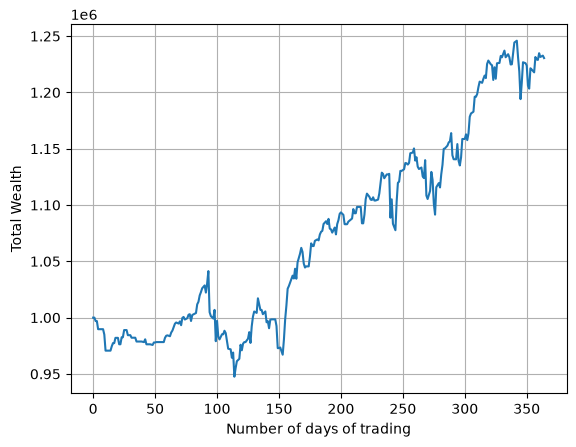

In [13]:
fig = plt.plot(W[:,0], W[:, 1])
plt.grid()
plt.xlabel("Number of days of trading")
plt.ylabel('Total Wealth');

## Student's t-test for momentum

The t-test checks whether the average daily log return over the last 120 observations is meaningfully different from zero, rather than a pattern that could reasonably be attributed to random price variation.

- **Null hypothesis ($H_0$):** We assume the mean daily log return is zero, so there is no statistically supported momentum.
- **Direction:** A positive sample mean suggests long momentum; a negative mean suggests short momentum.
- **t-statistic:** Measures how many estimated standard errors the observed mean is from zero. A larger absolute value represents stronger evidence against $H_0$.
- **p-value:** Measures how surprising the observed momentum would be if $H_0$ were true.
- **Decision:** With $\alpha=0.05$, momentum is considered statistically significant when `p_value < 0.05`. Otherwise, the evidence is not strong enough to act on the momentum signal.

For example, `direction='long'`, `t_statistic=2.1`, and `p_value=0.02` indicate statistically significant positive momentum at the 5% level. A p-value of `0.20` would not provide sufficient evidence to trade on the observed direction.

In [ ]:
from scipy.stats import ttest_1samp


def momentum_t_test(prices, alpha=0.05):
    """
    Test whether the mean daily log return is significantly
    greater or less than zero.
    """

    # Calculate daily log returns.
    log_returns = np.diff(
        np.log(np.asarray(prices, dtype=float))
    )

    # Determine the observed direction of momentum.
    direction = (
        "long"
        if np.mean(log_returns) > 0
        else "short"
    )

    # Test positive or negative momentum accordingly.
    alternative = (
        "greater"
        if direction == "long"
        else "less"
    )

    result = ttest_1samp(
        log_returns,
        popmean=0,
        alternative=alternative
    )

    return {
        "direction": direction,
        "t_statistic": result.statistic,
        "p_value": result.pvalue,
        "significant": result.pvalue < alpha,
        "alpha": alpha
    }




{'direction': 'long', 't_statistic': np.float64(1.0166735982124495), 'p_value': np.float64(0.155694379198621), 'significant': np.False_, 'alpha': 0.05}


In [18]:
# Test momentum using the final 120 observations.
cs.execute("""
    SELECT price
    FROM prices
    ORDER BY theday DESC
    LIMIT 120;
""")

recent_prices = np.array(
    [row[0] for row in reversed(cs.fetchall())],
    dtype=float
)

momentum_test = momentum_t_test(
    recent_prices,
    alpha=0.05
)

print(momentum_test)

{'direction': 'long', 't_statistic': np.float64(1.0166735982124495), 'p_value': np.float64(0.155694379198621), 'significant': np.False_, 'alpha': 0.05}


In [ ]:
class Performance:
    """Functions used to evaluate an investment strategy."""

    @staticmethod
    def returns(wealth):
        """Calculate returns from a wealth series."""
        wealth = np.asarray(wealth, dtype=float)

        if wealth.size < 2:
            raise ValueError(
                "At least two wealth values are required."
            )

        return wealth[1:] / wealth[:-1] - 1

    @staticmethod
    def annualized_return(rets, periods_per_year):
        """Compound periodic returns into an annual return."""
        rets = np.asarray(rets, dtype=float)

        if rets.size == 0:
            raise ValueError("Returns cannot be empty.")

        # we use the 1+return format
        growth = np.prod(1 + rets)

        return (
            growth ** (periods_per_year / rets.size)
            - 1
        )

    @staticmethod
    def annualized_volatility(rets, periods_per_year):
        """Convert return volatility to an annual value."""
        rets = np.asarray(rets, dtype=float)

        if rets.size < 2:
            raise ValueError(
                "At least two returns are required."
            )

        return (
            np.std(rets, ddof=1)
            * np.sqrt(periods_per_year)
        )

    @staticmethod
    def sharpe_ratio(
        rets,
        riskfree_rate,
        periods_per_year
    ):
        """Calculate annual excess return per unit of risk."""
        rets = np.asarray(rets, dtype=float)

        rf_per_period = (
            (1 + riskfree_rate)
            ** (1 / periods_per_year)
            - 1
        )

        excess_returns = rets - rf_per_period

        ann_vol = Performance.annualized_volatility(
            rets,
            periods_per_year
        )

        if ann_vol < 1e-12:
            return np.nan

        return (
            np.mean(excess_returns)
            * periods_per_year
            / ann_vol
        )

    @staticmethod
    def max_drawdown(wealth):
        """Find the largest loss from a previous wealth peak."""
        wealth = np.asarray(wealth, dtype=float)

        running_peak = np.maximum.accumulate(wealth)
        drawdowns = wealth / running_peak - 1

        return -np.min(drawdowns)

    @staticmethod
    def risk_free_wealth(
        initial_value,
        n_periods,
        riskfree_rate,
        periods_per_year
    ):
        """Create a wealth series growing at the risk-free rate."""
        rf_per_period = (
            (1 + riskfree_rate)
            ** (1 / periods_per_year)
            - 1
        )

        return (
            initial_value
            * (1 + rf_per_period)
            ** np.arange(n_periods)
        )

    @staticmethod
    def summary(
        wealth,
        riskfree_rate,
        periods_per_year
    ):
        """Return the main performance measures."""
        rets = Performance.returns(wealth)

        return {
            "terminal_wealth": wealth[-1],

            "annual_return":
                Performance.annualized_return(
                    rets,
                    periods_per_year
                ),

            "mean_daily_return":
                np.mean(rets),

            "annual_volatility":
                Performance.annualized_volatility(
                    rets,
                    periods_per_year
                ),

            "sharpe_ratio":
                Performance.sharpe_ratio(
                    rets,
                    riskfree_rate,
                    periods_per_year
                ),

            "max_drawdown":
                Performance.max_drawdown(wealth)
        }

    @staticmethod
    def best_and_worst_days(rets, dates):
        """Find the best and worst daily returns."""
        best_index = np.argmax(rets)
        worst_index = np.argmin(rets)

        return {
            "best_date": dates[best_index + 1],
            "best_return": rets[best_index],
            "worst_date": dates[worst_index + 1],
            "worst_return": rets[worst_index]
        }

In [22]:
# Use a 3% annual risk-free rate for the benchmark and Sharpe ratio.
risk_free_rate = 0.03
trading_days_per_year = 252


# Retrieve daily prices, positions, and strategy wealth.
cs.execute(
    """
    SELECT
        PR.theday,
        PR.price,
        PO.quantity,
        PO.quantity * PR.price + PO.cash AS wealth
    FROM prices AS PR
    JOIN positions AS PO
      ON PO.time_of_trade = (
          SELECT time_of_trade
          FROM positions
          WHERE instrument = 'SP500'
            AND time_of_trade <= PR.theday
          ORDER BY time_of_trade DESC
          LIMIT 1
      )
    WHERE PR.theday >= ?
    ORDER BY PR.theday ASC;
    """,
    (day1,)
)

performance_rows = cs.fetchall()

dates = np.array([
    row[0] for row in performance_rows
])

prices = np.array([
    row[1] for row in performance_rows
], dtype=float)

quantities = np.array([
    row[2] for row in performance_rows
], dtype=float)

strategy_wealth = np.array([
    row[3] for row in performance_rows
], dtype=float)

initial_wealth = strategy_wealth[0]


# Invest the same initial wealth in the S&P 500.
buy_hold_wealth = (
    initial_wealth
    * prices
    / prices[0]
)

In [23]:
# Create the 3% risk-free wealth benchmark.
risk_free_wealth_path = Performance.risk_free_wealth(
    initial_value=initial_wealth,
    n_periods=len(dates),
    riskfree_rate=risk_free_rate,
    periods_per_year=trading_days_per_year
)


# Calculate metrics for the three alternatives.
results = {
    "Momentum": Performance.summary(
        strategy_wealth,
        risk_free_rate,
        trading_days_per_year
    ),

    "Buy and hold": Performance.summary(
        buy_hold_wealth,
        risk_free_rate,
        trading_days_per_year
    ),

    "Risk free": Performance.summary(
        risk_free_wealth_path,
        risk_free_rate,
        trading_days_per_year
    )
}


# Find the best and worst strategy days.
strategy_returns = Performance.returns(
    strategy_wealth
)

extreme_days = Performance.best_and_worst_days(
    strategy_returns,
    dates
)


# Print the best and worst days.
print(
    f"Best day:  "
    f"{extreme_days['best_date']} "
    f"({extreme_days['best_return']:.2%})"
)

print(
    f"Worst day: "
    f"{extreme_days['worst_date']} "
    f"({extreme_days['worst_return']:.2%})"
)


# Print daily return statistics.
print(
    f"Mean daily return: "
    f"{np.mean(strategy_returns):.4%}"
)

print(
    f"Daily standard deviation: "
    f"{np.std(strategy_returns, ddof=1):.4%}"
)

print()


# Print the performance comparison table.
print(
    f"{'Strategy':<15}"
    f"{'Final wealth':>15}"
    f"{'Ann. return':>15}"
    f"{'Sharpe':>12}"
    f"{'Max DD':>12}"
)

for name, metrics in results.items():
    print(
        f"{name:<15}"
        f"{metrics['terminal_wealth']:>15,.2f}"
        f"{metrics['annual_return']:>15.2%}"
        f"{metrics['sharpe_ratio']:>12.2f}"
        f"{metrics['max_drawdown']:>12.2%}"
    )


# Keep the existing comparison chart compatible.
annual_savings_rate = risk_free_rate
savings_wealth = risk_free_wealth_path

Best day:  2021-02-01 (2.37%)
Worst day: 2020-09-03 (-3.50%)
Mean daily return: 0.0698%
Daily standard deviation: 0.7632%

Strategy          Final wealth    Ann. return      Sharpe      Max DD
Momentum          1,230,505.42         18.37%        1.21       9.01%
Buy and hold      1,382,217.60         30.10%        1.54       9.94%
Risk free         1,037,031.20          3.00%         nan      -0.00%


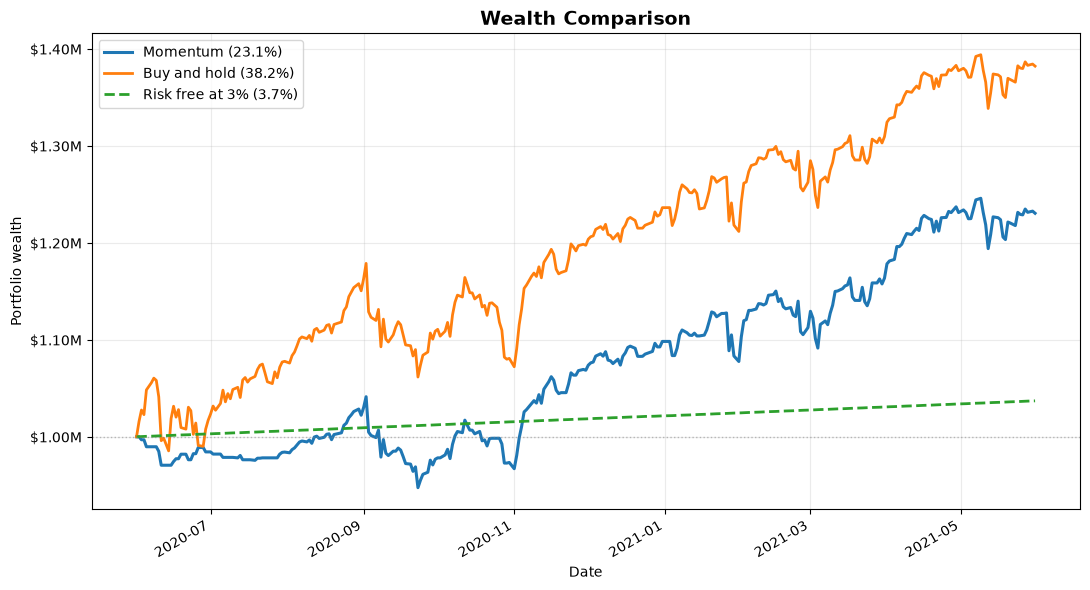

In [24]:
from matplotlib.ticker import FuncFormatter


# Convert database dates into datetime values.
chart_dates = [
    datetime.strptime(date, "%Y-%m-%d")
    for date in dates
]


# Calculate total returns for the chart legend.
momentum_return = (
    strategy_wealth[-1]
    / strategy_wealth[0]
    - 1
)

buy_hold_return = (
    buy_hold_wealth[-1]
    / buy_hold_wealth[0]
    - 1
)

risk_free_return = (
    risk_free_wealth_path[-1]
    / risk_free_wealth_path[0]
    - 1
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


ax.plot(
    chart_dates,
    strategy_wealth,
    linewidth=2.2,
    label=f"Momentum ({momentum_return:.1%})"
)

ax.plot(
    chart_dates,
    buy_hold_wealth,
    linewidth=2,
    label=f"Buy and hold ({buy_hold_return:.1%})"
)

ax.plot(
    chart_dates,
    risk_free_wealth_path,
    linewidth=2,
    linestyle="--",
    label=(
        f"Risk free at {risk_free_rate:.0%} "
        f"({risk_free_return:.1%})"
    )
)


# Show the common starting wealth.
ax.axhline(
    initial_wealth,
    color="gray",
    linewidth=1,
    alpha=0.5,
    linestyle=":"
)


ax.set_title(
    "Wealth Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Portfolio wealth")


# Display wealth in millions of dollars.
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, _: f"${value / 1_000_000:.2f}M"
    )
)


ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [25]:
# Calculate daily strategy and market returns.
strategy_returns = Performance.returns(strategy_wealth)
market_returns = Performance.returns(prices)

# Find the locations of the highest and lowest strategy returns.
best_index = np.argmax(strategy_returns) + 1
worst_index = np.argmin(strategy_returns) + 1


def show_day(label, index):
    """Print the relevant information for one trading day."""

    print(f"{label}: {dates[index]}")
    print(
        f"Strategy return: "
        f"{strategy_returns[index - 1]:.2%}"
    )
    print(
        f"S&P 500 return: "
        f"{market_returns[index - 1]:.2%}"
    )
    print(
        f"Position entering the day: "
        f"{quantities[index - 1]:.0f} units"
    )
    print(
        f"Position after the signal: "
        f"{quantities[index]:.0f} units"
    )
    print()


show_day("Best day", best_index)
show_day("Worst day", worst_index)

Best day: 2021-02-01
Strategy return: 2.37%
S&P 500 return: 2.52%
Position entering the day: 275 units
Position after the signal: 282 units

Worst day: 2020-09-03
Strategy return: -3.50%
S&P 500 return: -4.24%
Position entering the day: 240 units
Position after the signal: 204 units



- Best day — February 1, 2021: Return 2.37% because it was long while the S&P 500 increased 2.52%.
- Worst day — September 3, 2020: Return  -3.50% because it remained long while the S&P 500 fell 4.24%.